# BME280 — EDA e derivazione data-driven della topologia

Il dataset ufficiale del caso di studio è **gennaio 2025**. Il notebook risponde in modo riproducibile a cinque domande:

1. quante righe e quanti sensori contiene il dataset, e quali sensori possiedono coordinate utilizzabili;
2. quante macroaree geografiche emergono dai dati;
3. quante zone Edge candidate emergono in ogni macroarea;
4. quanto sono bilanciate le zone risultanti in termini di distanza e carico;
5. quanto si riduce il workload estraendo casualmente 150 sensori con seed fisso.

La topologia non viene fissata a priori. Le coordinate WGS84 vengono trasformate nel sistema europeo EPSG:3035 e su queste coordinate cartesiane vengono applicati due K-Means distinti: il primo individua le macroaree, il secondo opera separatamente dentro ciascuna macroarea. Per entrambi sono mostrati andamento dell'inertia (elbow method) e silhouette score. Il risultato è una topologia candidata Edge→Cloud: la capacità effettiva sarà verificata con benchmark, non dedotta dal solo clustering.


## 0. Preparazione

Da terminale, nella root del progetto:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install -r Sensor\notebooks\requirements.txt
jupyter lab
```

In [1]:
from pathlib import Path
import math
import os

# Evita il warning/leak noto di K-Means con MKL su Windows.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pyproj import Transformer

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT_DIR, *CURRENT_DIR.parents)
     if (path / 'Sensor' / 'dataset').is_dir()
     and (path / 'artifacts').is_dir()),
    None,
)
assert PROJECT_ROOT is not None, f'Root del progetto non trovata partendo da {CURRENT_DIR}'

DATASET_ROOT = PROJECT_ROOT / 'Sensor' / 'dataset'
CSV_PATH = DATASET_ROOT / '2025-01_bme280.csv'
assert CSV_PATH.exists(), CSV_PATH
CSV_PATH


WindowsPath('C:/Users/aless/GolandProjects/ProgettoSDDC/Sensor/dataset/2025-01_bme280.csv')

## 1. Colonne e anteprima

Prima di elaborare il dataset mostriamo soltanto le colonne e alcune righe grezze di esempio. Questa anteprima può includere record fuori gennaio: non alimenta alcuna analisi e il filtro temporale viene applicato all'inizio della scansione completa nella sezione successiva.


In [2]:
preview_df = pd.read_csv(
    CSV_PATH,
    sep=';',
    dtype='string',
    nrows=5,
    low_memory=False,
)
list(preview_df.columns)


['sensor_id',
 'sensor_type',
 'location',
 'lat',
 'lon',
 'timestamp',
 'pressure',
 'altitude',
 'pressure_sealevel',
 'temperature',
 'humidity']

### Prime righe

In [3]:
preview_df

,sensor_id,sensor_type,location,lat,lon,timestamp,pressure,altitude,pressure_sealevel,temperature,humidity
0,79419,BME280,68866,49.902,8.680,'2024-12-20 21:41:16',999.34,<NA>,<NA>,18.03,74.04
1,30343,BME280,17145,49.902,8.680,'2024-12-22 19:31:20',101540,<NA>,<NA>,0,52
2,47712,BME280,57457,51.634,5.886,2025-01-01T01:09:58,100400,<NA>,<NA>,8.6,85.1
3,48757,BME280,34554,51.60474072,5.87020530,2025-01-01T01:10:44,101300,<NA>,<NA>,7.9,93.8
4,88745,BME280,80338,47.870,18.180,2025-01-01T01:11:15,101875.34,<NA>,<NA>,11.30,48.53


### Colonne disponibili

In [4]:
pd.DataFrame({'colonna': preview_df.columns})

,colonna
0,sensor_id
1,sensor_type
2,location
3,lat
4,lon
5,timestamp
6,pressure
7,altitude
8,pressure_sealevel
9,temperature


## 2. Filtro temporale, numero di righe e sensori

Leggiamo il CSV a chunk senza caricare 6,36 GB in memoria. Prima di ogni aggregazione conserviamo esclusivamente le osservazioni con timestamp compreso tra il 1 gennaio 2025 incluso e il 1 febbraio escluso. Durante la stessa lettura contiamo le righe scartate e conserviamo solamente somma e numero delle coordinate di ciascun sensore.


In [5]:
SCAN_CHUNK_ROWS = 500_000
SCAN_COLUMNS = ['sensor_id', 'lat', 'lon', 'timestamp']
TIME_WINDOW_START = pd.Timestamp('2025-01-01T00:00:00Z')
TIME_WINDOW_END = pd.Timestamp('2025-02-01T00:00:00Z')

sensor_chunk_stats = []
raw_total_rows = 0
total_rows = 0
invalid_timestamp_rows = 0
outside_time_window_rows = 0
invalid_coordinate_rows = 0
observed_timestamp_min = None
observed_timestamp_max = None
retained_timestamp_min = None
retained_timestamp_max = None

for chunk in pd.read_csv(
    CSV_PATH,
    sep=';',
    usecols=SCAN_COLUMNS,
    dtype='string',
    chunksize=SCAN_CHUNK_ROWS,
    low_memory=False,
):
    raw_total_rows += len(chunk)
    timestamp_text = chunk['timestamp'].str.strip().str.strip("'\"")
    timestamps = pd.to_datetime(
        timestamp_text, format='mixed', errors='coerce', utc=True
    )
    valid_timestamps = timestamps.notna()
    invalid_timestamp_rows += int((~valid_timestamps).sum())
    if valid_timestamps.any():
        chunk_min = timestamps.loc[valid_timestamps].min()
        chunk_max = timestamps.loc[valid_timestamps].max()
        observed_timestamp_min = (
            chunk_min if observed_timestamp_min is None
            else min(observed_timestamp_min, chunk_min)
        )
        observed_timestamp_max = (
            chunk_max if observed_timestamp_max is None
            else max(observed_timestamp_max, chunk_max)
        )
    in_time_window = (
        valid_timestamps
        & timestamps.ge(TIME_WINDOW_START)
        & timestamps.lt(TIME_WINDOW_END)
    )
    outside_time_window_rows += int((valid_timestamps & ~in_time_window).sum())
    if in_time_window.any():
        retained_chunk_min = timestamps.loc[in_time_window].min()
        retained_chunk_max = timestamps.loc[in_time_window].max()
        retained_timestamp_min = (
            retained_chunk_min if retained_timestamp_min is None
            else min(retained_timestamp_min, retained_chunk_min)
        )
        retained_timestamp_max = (
            retained_chunk_max if retained_timestamp_max is None
            else max(retained_timestamp_max, retained_chunk_max)
        )
    chunk = chunk.loc[in_time_window]
    total_rows += len(chunk)

    sensor_id = chunk['sensor_id'].str.strip()
    valid_sensor_id = sensor_id.notna() & sensor_id.ne('')
    lat = pd.to_numeric(chunk['lat'], errors='coerce')
    lon = pd.to_numeric(chunk['lon'], errors='coerce')
    valid_coordinates = (
        lat.between(-90, 90)
        & lon.between(-180, 180)
        & ~(lat.abs().lt(0.01) & lon.abs().lt(0.01))
    ).fillna(False)
    invalid_coordinate_rows += int((~valid_coordinates).sum())

    scan_frame = pd.DataFrame({
        'sensor_id': sensor_id,
        'lat': lat.where(valid_coordinates),
        'lon': lon.where(valid_coordinates),
    }).loc[valid_sensor_id]

    sensor_chunk_stats.append(
        scan_frame.groupby('sensor_id', as_index=False).agg(
            rows=('sensor_id', 'size'),
            coordinate_rows=('lat', 'count'),
            lat_sum=('lat', 'sum'),
            lon_sum=('lon', 'sum'),
        )
    )

chunk_stats = pd.concat(sensor_chunk_stats, ignore_index=True)


## 3. Sensori localizzabili nel perimetro temporale

Dopo avere escluso le righe esterne a gennaio 2025, scartiamo soltanto i sensori che non possiedono alcuna coppia di coordinate valida. Per gli altri utilizziamo la posizione media osservata durante gennaio.


In [6]:
summary = pd.Series({
    'dimensione_csv_GB': CSV_PATH.stat().st_size / 1e9,
    'righe_nel_csv_fisico': raw_total_rows,
    'righe_gennaio_2025': total_rows,
    'righe_timestamp_non_valido': invalid_timestamp_rows,
    'righe_fuori_gennaio': outside_time_window_rows,
    'timestamp_minimo_osservato': observed_timestamp_min,
    'timestamp_massimo_osservato': observed_timestamp_max,
    'timestamp_minimo_utilizzato': retained_timestamp_min,
    'timestamp_massimo_utilizzato': retained_timestamp_max,
    'durata_osservata_giorni': (
        retained_timestamp_max - retained_timestamp_min
    ).total_seconds() / 86_400,
    'sensori_unici': chunk_stats['sensor_id'].nunique(),
})
summary.to_frame('valore')


,valore
dimensione_csv_GB,6.363
righe_nel_csv_fisico,80222756
righe_gennaio_2025,80222754
righe_timestamp_non_valido,0
righe_fuori_gennaio,2
timestamp_minimo_osservato,2024-12-20 21:41:16+00:00
timestamp_massimo_osservato,2025-01-29 23:59:59+00:00
timestamp_minimo_utilizzato,2025-01-01 01:09:58+00:00
timestamp_massimo_utilizzato,2025-01-29 23:59:59+00:00
durata_osservata_giorni,28.951


In [7]:
sensors = (
    chunk_stats.groupby('sensor_id', as_index=False)
    .agg(
        rows=('rows', 'sum'),
        coordinate_rows=('coordinate_rows', 'sum'),
        lat_sum=('lat_sum', 'sum'),
        lon_sum=('lon_sum', 'sum'),
    )
)
sensors['lat'] = sensors['lat_sum'] / sensors['coordinate_rows']
sensors['lon'] = sensors['lon_sum'] / sensors['coordinate_rows']
OBSERVATION_DAYS = (
    retained_timestamp_max - retained_timestamp_min
).total_seconds() / 86_400
assert OBSERVATION_DAYS > 0
sensors['rows_per_day'] = sensors['rows'] / OBSERVATION_DAYS

usable_sensors = (
    sensors.loc[sensors['coordinate_rows'].gt(0)]
    .dropna(subset=['lat', 'lon'])
    .copy()
)

filter_summary = pd.Series({
    'sensori_prima_del_filtro': len(sensors),
    'sensori_senza_coordinate': len(sensors) - len(usable_sensors),
    'sensori_da_cui_estrarre': len(usable_sensors),
})
filter_summary.to_frame('valore')


,valore
sensori_prima_del_filtro,5306
sensori_senza_coordinate,18
sensori_da_cui_estrarre,5288


### Interpretazione architetturale

La validazione di temperatura, umidità e pressione resta responsabilità dell'Edge. In questa fase servono soltanto ID e coordinate per costruire il campione geografico.


## 4. Perimetro europeo e selezione casuale del workload operativo

Prima di derivare macroaree ed Edge restringiamo il workload a un rettangolo geografico europeo esplicito e parametrizzato. Da questa popolazione estraiamo casualmente **150 ID sensore** con un seed fisso: ogni esecuzione seleziona gli stessi sensori, senza usare cluster o Edge calcolati in precedenza. Il rettangolo è un'approssimazione operativa, non una definizione geopolitica dei confini europei.

Da questo punto in poi entrambi i K-Means lavorano esclusivamente sui 150 sensori selezionati.


In [8]:
SAMPLE_SENSOR_COUNT = 150
SAMPLE_RANDOM_SEED = 42
EUROPE_BOUNDS = {
    'latitude_min': 34.0,
    'latitude_max': 72.0,
    'longitude_min': -25.0,
    'longitude_max': 45.0,
}

europe_sensors = usable_sensors.loc[
    usable_sensors['lat'].between(
        EUROPE_BOUNDS['latitude_min'], EUROPE_BOUNDS['latitude_max']
    )
    & usable_sensors['lon'].between(
        EUROPE_BOUNDS['longitude_min'], EUROPE_BOUNDS['longitude_max']
    )
].copy()
eligible_sensor_ids = europe_sensors['sensor_id'].drop_duplicates()
assert SAMPLE_SENSOR_COUNT <= len(eligible_sensor_ids)

sampled_sensor_ids = (
    eligible_sensor_ids.sample(
        n=SAMPLE_SENSOR_COUNT,
        replace=False,
        random_state=SAMPLE_RANDOM_SEED,
    )
    .sort_values()
    .reset_index(drop=True)
)
sampled_sensor_id_set = set(sampled_sensor_ids.tolist())
eligible = (
    europe_sensors.loc[
        europe_sensors['sensor_id'].isin(sampled_sensor_id_set)
    ]
    .copy()
    .reset_index(drop=True)
)
assert eligible['sensor_id'].nunique() == SAMPLE_SENSOR_COUNT

sampled_rows = int(eligible['rows'].sum())
full_rows = int(total_rows)
retained_rows_pct = 100 * sampled_rows / full_rows
january_estimated_bytes = (
    CSV_PATH.stat().st_size * full_rows / raw_total_rows
)
estimated_sample_bytes = (
    CSV_PATH.stat().st_size * sampled_rows / raw_total_rows
)

sample_reduction = pd.Series({
    'sensori_totali_nel_csv': int(len(sensors)),
    'sensori_localizzabili_globali': int(len(usable_sensors)),
    'sensori_nel_perimetro_europeo': int(len(eligible_sensor_ids)),
    'sensori_selezionati': int(eligible['sensor_id'].nunique()),
    'righe_nel_csv_fisico': int(raw_total_rows),
    'righe_gennaio_2025': full_rows,
    'righe_del_campione': sampled_rows,
    'righe_mantenute_su_gennaio_pct': retained_rows_pct,
    'riduzione_righe_gennaio_pct': 100 - retained_rows_pct,
    'dimensione_csv_fisico_GB': CSV_PATH.stat().st_size / 1e9,
    'dimensione_gennaio_stimata_GB': january_estimated_bytes / 1e9,
    'dimensione_campione_stimata_GB': estimated_sample_bytes / 1e9,
})
sample_reduction.to_frame('valore')


,valore
sensori_totali_nel_csv,"5,306.000"
sensori_localizzabili_globali,"5,288.000"
sensori_nel_perimetro_europeo,"5,102.000"
sensori_selezionati,150.000
righe_nel_csv_fisico,"80,222,756.000"
righe_gennaio_2025,"80,222,754.000"
righe_del_campione,"2,449,631.000"
righe_mantenute_su_gennaio_pct,3.054
riduzione_righe_gennaio_pct,96.946
dimensione_csv_fisico_GB,6.363


## 5. Funzioni comuni per K-Means, elbow e silhouette

Il valore di elbow è la proposta automatica ottenuta dalla massima distanza della curva normalizzata dalla retta che collega primo e ultimo punto. La silhouette resta visibile come controllo diagnostico, ma non viene massimizzata alla cieca: con coordinate geografiche può favorire la separazione di pochi sensori molto lontani. Ogni scelta resta sovrascrivibile esplicitamente.


In [9]:
RANDOM_STATE = 42
KMEANS_N_INIT = 20
SILHOUETTE_SAMPLE_SIZE = 2_000
ELBOW_SILHOUETTE_RELATIVE_TOLERANCE = 0.05
EARTH_RADIUS_KM = 6_371.0088

EUROPE_TRANSFORMER = Transformer.from_crs(
    'EPSG:4326', 'EPSG:3035', always_xy=True
)

def project_europe_km(frame):
    easting_m, northing_m = EUROPE_TRANSFORMER.transform(
        frame['lon'].to_numpy(), frame['lat'].to_numpy()
    )
    return np.column_stack([easting_m, northing_m]) / 1_000.0

def distances_from_centroid_km(frame):
    if frame.empty:
        return np.array([], dtype=float)
    lat = np.radians(frame['lat'].to_numpy())
    lon = np.radians(frame['lon'].to_numpy())
    lat0 = np.radians(frame['lat'].mean())
    lon0 = np.radians(frame['lon'].mean())
    dlat = lat - lat0
    dlon = lon - lon0
    haversine = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat0) * np.cos(lat) * np.sin(dlon / 2) ** 2
    )
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(haversine))

def geographic_radius_km(frame):
    distances = distances_from_centroid_km(frame)
    return 0.0 if distances.size == 0 else float(distances.max())

def geographic_dispersion(frame):
    distances = distances_from_centroid_km(frame)
    if distances.size == 0:
        return pd.Series({
            'mean_distance_from_centroid_km': np.nan,
            'p95_distance_from_centroid_km': np.nan,
            'max_radius_km': np.nan,
        })
    return pd.Series({
        'mean_distance_from_centroid_km': float(distances.mean()),
        'p95_distance_from_centroid_km': float(np.quantile(distances, 0.95)),
        'max_radius_km': float(distances.max()),
    })

def evaluate_k_values(features, k_values, geographic_frame=None):
    if geographic_frame is not None:
        assert len(geographic_frame) == len(features)
    rows = []
    for k in k_values:
        if k < 1 or k > len(features):
            continue
        model = KMeans(
            n_clusters=k,
            n_init=KMEANS_N_INIT,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(features)
        sizes = np.bincount(labels, minlength=k)
        silhouette = np.nan
        if 1 < k < len(features):
            silhouette = silhouette_score(
                features,
                labels,
                sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(features)),
                random_state=RANDOM_STATE,
            )
        max_radius = np.nan
        if geographic_frame is not None:
            max_radius = max(
                geographic_radius_km(
                    geographic_frame.iloc[np.flatnonzero(labels == cluster_id)]
                )
                for cluster_id in range(k)
            )
        rows.append({
            'k': k,
            'inertia': model.inertia_,
            'silhouette': silhouette,
            'min_cluster_size': int(sizes.min()),
            'max_cluster_size': int(sizes.max()),
            'max_radius_km': max_radius,
        })
    return pd.DataFrame(rows)

def detect_elbow(metrics):
    curve = metrics.dropna(subset=['inertia']).sort_values('k')
    if len(curve) < 3:
        return int(curve.iloc[-1]['k'])
    x = curve['k'].to_numpy(dtype=float)
    y = curve['inertia'].to_numpy(dtype=float)
    x = (x - x.min()) / (x.max() - x.min())
    y = (y - y.min()) / (y.max() - y.min())
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    points = np.column_stack([x, y])
    direction = p2 - p1
    offsets = points - p1
    distances = np.abs(
        direction[0] * offsets[:, 1] - direction[1] * offsets[:, 0]
    ) / np.linalg.norm(direction)
    return int(curve.iloc[int(np.argmax(distances))]['k'])

def best_silhouette_k(metrics):
    valid = metrics.dropna(subset=['silhouette'])
    return None if valid.empty else int(valid.loc[valid['silhouette'].idxmax(), 'k'])

def select_k_with_elbow_and_silhouette(metrics):
    elbow = detect_elbow(metrics)
    global_silhouette_k = best_silhouette_k(metrics)
    candidate_min = max(2, elbow - 1)
    candidate_max = min(int(metrics['k'].max()), elbow + 1)
    candidates = metrics.loc[
        metrics['k'].between(candidate_min, candidate_max)
        & metrics['silhouette'].notna()
    ]
    candidate_k_values = candidates['k'].astype(int).tolist()
    if candidates.empty:
        return {
            'selected_k': 1,
            'elbow_k': elbow,
            'candidate_k_values': candidate_k_values,
            'global_silhouette_k': global_silhouette_k,
            'candidate_best_k': None,
            'elbow_silhouette': np.nan,
            'candidate_best_silhouette': np.nan,
            'relative_silhouette_loss': np.nan,
            'selection_reason': 'single_cluster_only',
        }

    best_row = candidates.loc[candidates['silhouette'].idxmax()]
    elbow_row = candidates.loc[candidates['k'].eq(elbow)].iloc[0]
    best_k = int(best_row['k'])
    best_score = float(best_row['silhouette'])
    elbow_score = float(elbow_row['silhouette'])
    relative_loss = (
        (best_score - elbow_score) / max(abs(best_score), 1e-12)
    )
    prefer_elbow = (
        relative_loss <= ELBOW_SILHOUETTE_RELATIVE_TOLERANCE
    )
    return {
        'selected_k': elbow if prefer_elbow else best_k,
        'elbow_k': elbow,
        'candidate_k_values': candidate_k_values,
        'global_silhouette_k': global_silhouette_k,
        'candidate_best_k': best_k,
        'elbow_silhouette': elbow_score,
        'candidate_best_silhouette': best_score,
        'relative_silhouette_loss': relative_loss,
        'selection_reason': (
            'elbow_within_silhouette_tolerance'
            if prefer_elbow else 'max_silhouette_near_elbow'
        ),
    }

def plot_k_diagnostics(metrics, title, selected_k=None, axes=None):
    if axes is None:
        _, axes = plt.subplots(1, 2, figsize=(15, 5))
    elbow = detect_elbow(metrics)
    silhouette_k = best_silhouette_k(metrics)

    axes[0].plot(metrics['k'], metrics['inertia'], marker='o', color='#2563eb')
    axes[0].axvline(elbow, color='#f59e0b', linestyle='--', label=f'elbow={elbow}')
    axes[0].set(title=f'{title} — Elbow method', xlabel='k', ylabel='Inertia / WCSS')

    silhouette_data = metrics.dropna(subset=['silhouette'])
    axes[1].plot(
        silhouette_data['k'], silhouette_data['silhouette'],
        marker='s', color='#dc2626',
    )
    if silhouette_k is not None:
        axes[1].axvline(
            silhouette_k, color='#16a34a', linestyle=':',
            label=f'max silhouette={silhouette_k}',
        )
    axes[1].set(
        title=f'{title} — Silhouette score',
        xlabel='k', ylabel='Silhouette',
    )

    if selected_k is not None:
        for axis in axes:
            axis.axvline(
                selected_k, color='#7c3aed', linewidth=2,
                label=f'k selezionato={selected_k}',
            )
    for axis in axes:
        axis.legend()
    return elbow, silhouette_k


## 6. Primo K-Means — scoperta delle macroaree

Il primo K-Means usa le coordinate cartesiane europee EPSG:3035 espresse in chilometri. `k=1` viene misurato soltanto come riferimento per l'inertia, ma non è una topologia globale candidata. Individuato l'elbow `k_e`, confrontiamo `{k_e-1, k_e, k_e+1}`. Manteniamo l'elbow se la sua perdita relativa di silhouette rispetto al candidato migliore non supera il 5%; altrimenti scegliamo il candidato con silhouette massima. La silhouette massima sull'intero intervallo resta visibile come confronto.


In [10]:
K_MACRO_MIN = 1
K_MACRO_MAX = 12

# None applica elbow, candidati adiacenti e tolleranza silhouette del 5%.
# Impostare un intero soltanto per documentare una scelta architetturale motivata.
SELECTED_K_MACRO = None

macro_features = project_europe_km(eligible)
macro_metrics = evaluate_k_values(
    macro_features,
    range(K_MACRO_MIN, K_MACRO_MAX + 1),
    geographic_frame=eligible,
)
macro_metrics


,k,inertia,silhouette,min_cluster_size,max_cluster_size,max_radius_km
0,1,"121,599,867.361",NaN,150,150,"2,473.110"
1,2,"58,357,269.370",0.506,61,89,"1,703.014"
2,3,"40,162,593.956",0.525,13,87,"1,692.299"
3,4,"28,812,655.483",0.496,13,70,"1,643.467"
4,5,"21,395,134.454",0.515,4,68,"1,507.332"
5,6,"17,383,896.228",0.495,4,44,"1,560.601"
6,7,"13,816,746.802",0.503,4,43,"1,545.963"
7,8,"11,356,378.511",0.515,1,40,"1,090.564"
8,9,"9,768,445.475",0.516,1,34,"1,090.564"
9,10,"8,582,042.233",0.510,1,33,"1,093.304"


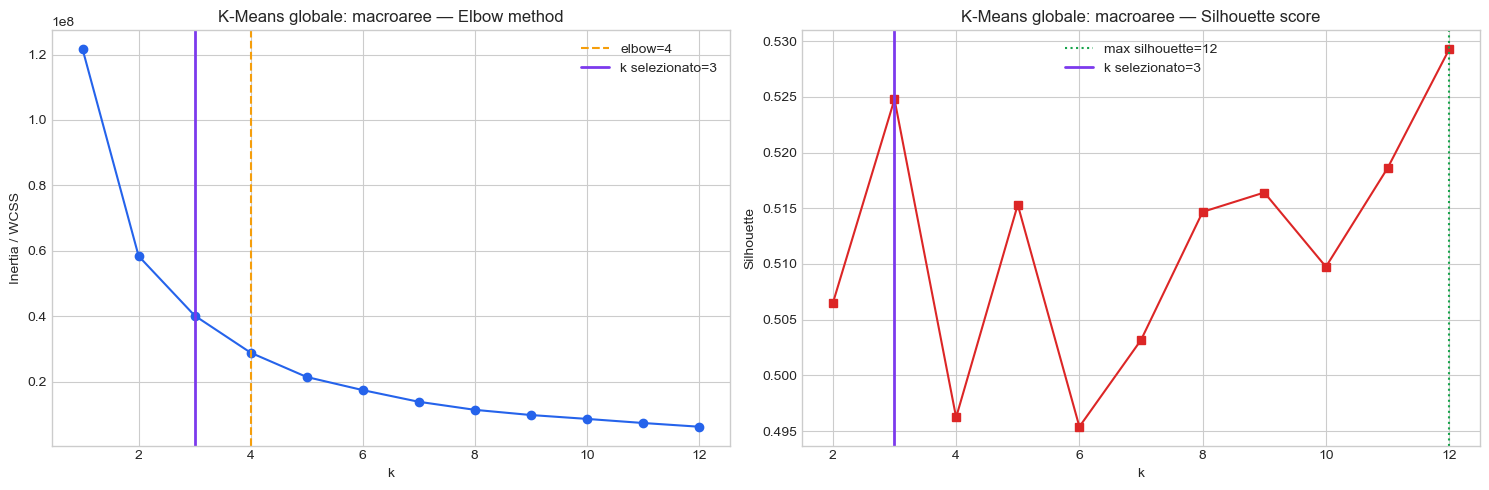

k_elbow                                                       4
candidati_attorno_elbow                               [3, 4, 5]
k_massima_silhouette_globale                                 12
k_massima_silhouette_tra_candidati                            3
silhouette_elbow                                          0.496
silhouette_migliore_candidati                             0.525
perdita_relativa_silhouette_pct                           5.443
criterio_selezione                    max_silhouette_near_elbow
k_automatico                                                  3
k_selezionato                                                 3
dtype: object

In [11]:
macro_selection = select_k_with_elbow_and_silhouette(macro_metrics)
auto_k_macro = macro_selection['selected_k']
selected_k_macro = auto_k_macro if SELECTED_K_MACRO is None else SELECTED_K_MACRO

assert selected_k_macro in macro_metrics['k'].to_numpy(), selected_k_macro
plot_k_diagnostics(
    macro_metrics,
    title='K-Means globale: macroaree',
    selected_k=selected_k_macro,
)
plt.tight_layout()
plt.show()

pd.Series({
    'k_elbow': macro_selection['elbow_k'],
    'candidati_attorno_elbow': str(macro_selection['candidate_k_values']),
    'k_massima_silhouette_globale': macro_selection['global_silhouette_k'],
    'k_massima_silhouette_tra_candidati': macro_selection['candidate_best_k'],
    'silhouette_elbow': macro_selection['elbow_silhouette'],
    'silhouette_migliore_candidati': macro_selection['candidate_best_silhouette'],
    'perdita_relativa_silhouette_pct': (
        100 * macro_selection['relative_silhouette_loss']
    ),
    'criterio_selezione': macro_selection['selection_reason'],
    'k_automatico': auto_k_macro,
    'k_selezionato': selected_k_macro,
})


In [12]:
macro_model = KMeans(
    n_clusters=selected_k_macro,
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_STATE,
)
eligible['macroarea_id'] = macro_model.fit_predict(macro_features)

macro_summary = (
    eligible.groupby('macroarea_id', as_index=False)
    .agg(
        sensors=('sensor_id', 'nunique'),
        rows=('rows', 'sum'),
        latitude=('lat', 'mean'),
        longitude=('lon', 'mean'),
        rows_per_day=('rows_per_day', 'sum'),
    )
    .sort_values('sensors', ascending=False)
)
macro_dispersion = (
    eligible.groupby('macroarea_id')[['lat', 'lon']]
    .apply(geographic_dispersion)
    .reset_index()
)
macro_summary = macro_summary.merge(
    macro_dispersion, on='macroarea_id', how='left'
)
macro_summary['estimated_events_per_second'] = (
    macro_summary['rows_per_day'] / 86_400
)
macro_summary['workload_share_pct'] = (
    100 * macro_summary['rows_per_day'] / macro_summary['rows_per_day'].sum()
)
macro_summary['is_singleton'] = macro_summary['sensors'].eq(1)
macro_summary = macro_summary.sort_values(
    'estimated_events_per_second', ascending=False
)
macro_summary


,macroarea_id,sensors,rows,latitude,longitude,rows_per_day,mean_distance_from_centroid_km,p95_distance_from_centroid_km,max_radius_km,estimated_events_per_second,workload_share_pct,is_singleton
0,2,87,1409584,50.839,8.535,"48,687.938",387.179,841.867,"1,692.299",0.564,57.543,False
1,0,50,884630,45.042,22.078,"30,555.689",415.334,794.525,"1,198.834",0.354,36.113,False
2,1,13,155417,50.878,37.547,"5,368.203",758.156,"1,305.450","1,306.112",0.062,6.345,False


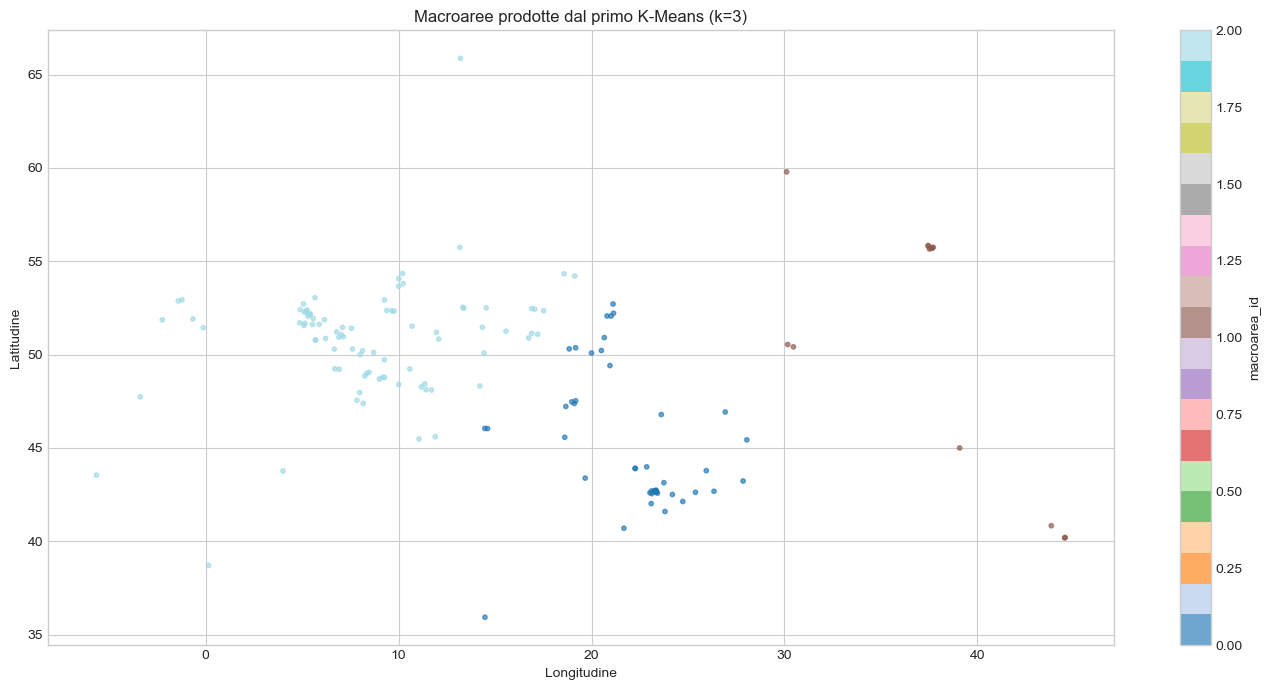

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    eligible['lon'], eligible['lat'],
    c=eligible['macroarea_id'], cmap='tab20',
    s=10, alpha=.65,
)
ax.set(
    title=f'Macroaree prodotte dal primo K-Means (k={selected_k_macro})',
    xlabel='Longitudine', ylabel='Latitudine',
)
plt.colorbar(scatter, ax=ax, label='macroarea_id')
plt.tight_layout()
plt.show()


## 7. Secondo K-Means — determinazione delle zone Edge

Per ogni macroarea viene applicata la stessa regola sulle coordinate EPSG:3035: confrontiamo `{k_e-1, k_e, k_e+1}` e manteniamo l'elbow se la sua perdita relativa di silhouette non supera il 5%; altrimenti scegliamo il candidato con silhouette massima. Il raggio, la numerosità e il rate delle zone vengono calcolati soltanto dopo il clustering come verifiche operative e non influenzano la scelta di `k`.


In [14]:
MAX_K_EDGE_SEARCH = 12

# Permette di sostituire il k automatico dopo avere osservato i grafici.
# Esempio: EDGE_K_OVERRIDES = {0: 4, 2: 3}
EDGE_K_OVERRIDES = {}

def choose_edge_k(metrics):
    return select_k_with_elbow_and_silhouette(metrics)

edge_metrics_by_macroarea = {}
edge_choices = []
edge_frames = []

for macroarea_id, area in eligible.groupby('macroarea_id'):
    area = area.copy()
    n_sensors = area['sensor_id'].nunique()
    edge_features = project_europe_km(area)
    k_max = min(
        MAX_K_EDGE_SEARCH,
        n_sensors,
    )
    metrics = evaluate_k_values(
        edge_features,
        range(1, k_max + 1),
        geographic_frame=area,
    )
    k_selection = choose_edge_k(metrics)
    selected_k = k_selection['selected_k']
    automatic_k = selected_k
    selection_reason = k_selection['selection_reason']
    selected_k = EDGE_K_OVERRIDES.get(int(macroarea_id), automatic_k)
    if selected_k is not None and selected_k not in metrics['k'].to_numpy():
        raise ValueError(
            f'Override k={selected_k} non valutato per macroarea {macroarea_id}'
        )
    if selected_k != automatic_k:
        selection_reason = 'manual_override'
    selected_metrics = metrics.loc[metrics['k'].eq(selected_k)].iloc[0]

    edge_metrics_by_macroarea[int(macroarea_id)] = metrics
    edge_choices.append({
        'macroarea_id': int(macroarea_id),
        'sensors': n_sensors,
        'k_max_valutato': k_max,
        'k_elbow': k_selection['elbow_k'],
        'candidati_attorno_elbow': str(k_selection['candidate_k_values']),
        'k_best_silhouette': k_selection['global_silhouette_k'],
        'k_best_silhouette_tra_candidati': k_selection['candidate_best_k'],
        'silhouette_elbow': k_selection['elbow_silhouette'],
        'silhouette_migliore_candidati': (
            k_selection['candidate_best_silhouette']
        ),
        'perdita_relativa_silhouette_pct': (
            100 * k_selection['relative_silhouette_loss']
        ),
        'k_automatico': automatic_k,
        'k_edge': selected_k,
        'max_radius_km': selected_metrics['max_radius_km'],
        'selection_reason': selection_reason,
        'status': 'selected' if selected_k is not None else 'not_selected',
    })

    if selected_k is not None:
        model = KMeans(
            n_clusters=selected_k,
            n_init=KMEANS_N_INIT,
            random_state=RANDOM_STATE,
        )
        area['edge_cluster'] = model.fit_predict(edge_features)
        area['edge_id'] = (
            'edge-m' + area['macroarea_id'].astype(str)
            + '-' + area['edge_cluster'].astype(str)
        )
        edge_frames.append(area)

edge_choices = pd.DataFrame(edge_choices).sort_values('macroarea_id')
edge_choices


,macroarea_id,sensors,k_max_valutato,k_elbow,candidati_attorno_elbow,k_best_silhouette,k_best_silhouette_tra_candidati,silhouette_elbow,silhouette_migliore_candidati,perdita_relativa_silhouette_pct,k_automatico,k_edge,max_radius_km,selection_reason,status
0,0,50,12,4,"[3, 4, 5]",3,3,0.638,0.644,1.018,4,4,493.091,elbow_within_silhouette_tolerance,selected
1,1,13,12,3,"[2, 3, 4]",4,4,0.782,0.813,3.759,3,3,537.972,elbow_within_silhouette_tolerance,selected
2,2,87,12,5,"[4, 5, 6]",8,6,0.439,0.479,8.229,6,6,454.509,max_silhouette_near_elbow,selected


### Elbow e silhouette del secondo K-Means

Ogni riga mostra una macroarea: a sinistra l'inertia, a destra la silhouette. Le figure vengono spezzate in gruppi di quattro macroaree per restare leggibili.


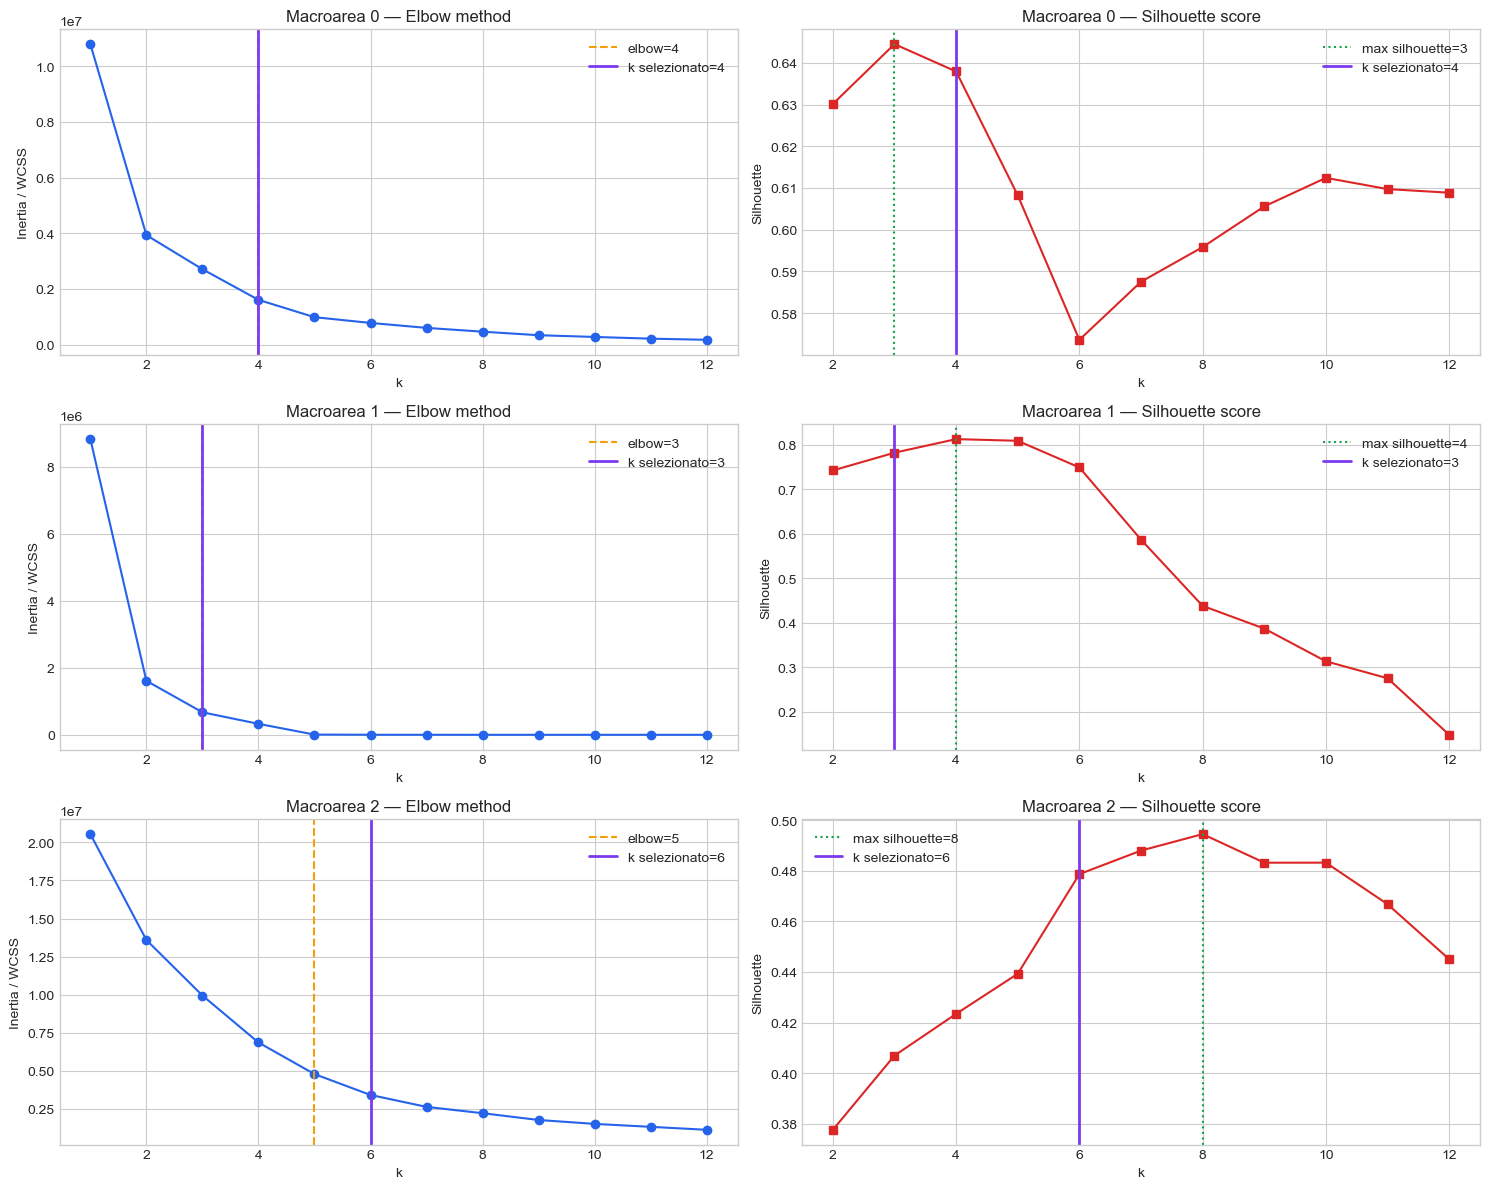

In [15]:
PLOTS_PER_FIGURE = 4
plot_ids = list(edge_metrics_by_macroarea)

for start in range(0, len(plot_ids), PLOTS_PER_FIGURE):
    chunk = plot_ids[start:start + PLOTS_PER_FIGURE]
    fig, axes = plt.subplots(len(chunk), 2, figsize=(15, 4 * len(chunk)), squeeze=False)
    for row_index, macroarea_id in enumerate(chunk):
        choice = edge_choices.loc[
            edge_choices['macroarea_id'] == macroarea_id
        ].iloc[0]
        selected_k = None if pd.isna(choice['k_edge']) else int(choice['k_edge'])
        plot_k_diagnostics(
            edge_metrics_by_macroarea[macroarea_id],
            title=f'Macroarea {macroarea_id}',
            selected_k=selected_k,
            axes=axes[row_index],
        )
    plt.tight_layout()
    plt.show()


In [16]:
if edge_frames:
    topology = pd.concat(edge_frames, ignore_index=True)
    edge_summary = (
        topology.groupby(['macroarea_id', 'edge_id'], as_index=False)
        .agg(
            sensors=('sensor_id', 'nunique'),
            rows=('rows', 'sum'),
            latitude=('lat', 'mean'),
            longitude=('lon', 'mean'),
            rows_per_day=('rows_per_day', 'sum'),
        )
    )
else:
    topology = pd.DataFrame()
    edge_summary = pd.DataFrame()

edge_summary


,macroarea_id,edge_id,sensors,rows,latitude,longitude,rows_per_day
0,0,edge-m0-0,32,476722,43.081,23.798,"16,466.285"
1,0,edge-m0-1,10,141171,51.035,20.424,"4,876.137"
2,0,edge-m0-2,1,9272,35.928,14.477,320.261
3,0,edge-m0-3,7,257465,46.749,17.662,"8,893.007"
4,1,edge-m1-0,7,84505,56.321,36.501,"2,918.857"
5,1,edge-m1-1,4,38093,41.553,42.994,"1,315.757"
6,1,edge-m1-2,2,32819,50.479,30.316,"1,133.589"
7,2,edge-m2-0,37,638120,51.922,6.959,"22,041.075"
8,2,edge-m2-1,1,16603,65.870,13.210,573.478
9,2,edge-m2-2,17,206592,52.175,15.464,"7,135.821"


## 8. Metriche operative per valutare Edge→Cloud ed Edge→Fog→Cloud

Il K-Means descrive la distribuzione geografica, ma non decide da solo dove eseguire le elaborazioni. Per ogni zona misuriamo quindi raggio massimo, sensori e rate storico; per ogni macroarea aggiungiamo numero di Edge e una stima del numero di messaggi che attraverserebbero il collegamento WAN. La stima assume finestre Edge di 5 minuti e un'eventuale aggregazione Fog di 15 minuti, come nella configurazione corrente. Non è una misura in byte: dimensione serializzata, latenza, banda e costo CPU dovranno essere misurati nei benchmark.


In [17]:
if not topology.empty:
    edge_radius = (
        topology.groupby(['macroarea_id', 'edge_id'])[['lat', 'lon']]
        .apply(geographic_radius_km)
        .rename('max_radius_km')
        .reset_index()
    )
    edge_operational = edge_summary.merge(
        edge_radius, on=['macroarea_id', 'edge_id'], how='left'
    )
    edge_operational['estimated_events_per_second'] = (
        edge_operational['rows_per_day'] / 86_400
    )
    edge_operational['load_share_pct'] = (
        100 * edge_operational['rows_per_day'] / edge_operational['rows_per_day'].sum()
    )
    edge_operational = edge_operational.sort_values(
        'estimated_events_per_second', ascending=False
    )
else:
    edge_operational = pd.DataFrame()

EDGE_WINDOW_SECONDS = 5 * 60
FOG_WINDOW_SECONDS = 15 * 60
SECONDS_PER_DAY = 86_400

if not edge_operational.empty:
    edge_counts = (
        edge_operational.groupby('macroarea_id', as_index=False)
        .agg(edge_nodes=('edge_id', 'nunique'))
    )
    macroarea_operational = macro_summary.merge(
        edge_counts, on='macroarea_id', how='left'
    )
    macroarea_operational['direct_edge_to_cloud_messages_per_day'] = (
        macroarea_operational['edge_nodes']
        * SECONDS_PER_DAY / EDGE_WINDOW_SECONDS
    )
    macroarea_operational['fog_to_cloud_messages_per_day'] = (
        SECONDS_PER_DAY / FOG_WINDOW_SECONDS
    )
    macroarea_operational['wan_message_reduction_pct_if_fog'] = (
        100 * (
            1 - macroarea_operational['fog_to_cloud_messages_per_day']
            / macroarea_operational['direct_edge_to_cloud_messages_per_day']
        )
    )
    macroarea_operational = macroarea_operational.sort_values(
        'estimated_events_per_second', ascending=False
    )
else:
    macroarea_operational = pd.DataFrame()

REPLAY_FACTORS = [1, 100, 1_000]
natural_events_per_second = (
    0.0 if edge_operational.empty
    else edge_operational['estimated_events_per_second'].sum()
)
replay_load_scenarios = pd.DataFrame({
    'replay_factor': REPLAY_FACTORS,
    'total_events_per_second': [
        natural_events_per_second * factor for factor in REPLAY_FACTORS
    ],
})
display(edge_operational)
display(macroarea_operational)
replay_load_scenarios


,macroarea_id,edge_id,sensors,rows,latitude,longitude,rows_per_day,max_radius_km,estimated_events_per_second,load_share_pct
7,2,edge-m2-0,37,638120,51.922,6.959,"22,041.075",345.861,0.255,26.050
0,0,edge-m0-0,32,476722,43.081,23.798,"16,466.285",493.091,0.191,19.461
12,2,edge-m2-5,23,380146,48.447,9.545,"13,130.487",363.265,0.152,15.519
3,0,edge-m0-3,7,257465,46.749,17.662,"8,893.007",256.927,0.103,10.510
9,2,edge-m2-2,17,206592,52.175,15.464,"7,135.821",423.380,0.083,8.434
1,0,edge-m0-1,10,141171,51.035,20.424,"4,876.137",192.154,0.056,5.763
11,2,edge-m2-4,6,97052,51.459,-1.509,"3,352.239",435.166,0.039,3.962
4,1,edge-m1-0,7,84505,56.321,36.501,"2,918.857",537.972,0.034,3.450
10,2,edge-m2-3,3,71071,42.005,-0.501,"2,454.838",454.509,0.028,2.901
5,1,edge-m1-1,4,38093,41.553,42.994,"1,315.757",497.040,0.015,1.555


,macroarea_id,sensors,rows,latitude,longitude,rows_per_day,mean_distance_from_centroid_km,p95_distance_from_centroid_km,max_radius_km,estimated_events_per_second,workload_share_pct,is_singleton,edge_nodes,direct_edge_to_cloud_messages_per_day,fog_to_cloud_messages_per_day,wan_message_reduction_pct_if_fog
0,2,87,1409584,50.839,8.535,"48,687.938",387.179,841.867,"1,692.299",0.564,57.543,False,6,"1,728.000",96.000,94.444
1,0,50,884630,45.042,22.078,"30,555.689",415.334,794.525,"1,198.834",0.354,36.113,False,4,"1,152.000",96.000,91.667
2,1,13,155417,50.878,37.547,"5,368.203",758.156,"1,305.450","1,306.112",0.062,6.345,False,3,864.000,96.000,88.889


,replay_factor,total_events_per_second
0,1,0.979
1,100,97.930
2,1000,979.304


## 9. Esportazione degli artefatti riproducibili

Gli output conservano metriche e assegnazioni calcolate sui 150 sensori selezionati, permettendo di giustificare ogni scelta senza modificare il CSV originale.


In [18]:
OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

macro_metrics.to_csv(OUTPUT_DIR / 'kmeans_macro_metrics.csv', index=False)
macro_summary.to_csv(OUTPUT_DIR / 'macroarea_summary.csv', index=False)
macroarea_operational.to_csv(
    OUTPUT_DIR / 'macroarea_operational_summary.csv', index=False
)
edge_choices.to_csv(OUTPUT_DIR / 'kmeans_edge_choices.csv', index=False)
edge_operational.to_csv(OUTPUT_DIR / 'edge_operational_summary.csv', index=False)
replay_load_scenarios.to_csv(
    OUTPUT_DIR / 'replay_load_scenarios.csv', index=False
)

edge_metrics_export = pd.concat(
    [
        metrics.assign(macroarea_id=macroarea_id)
        for macroarea_id, metrics in edge_metrics_by_macroarea.items()
    ],
    ignore_index=True,
) if edge_metrics_by_macroarea else pd.DataFrame()
edge_metrics_export.to_csv(OUTPUT_DIR / 'kmeans_edge_metrics.csv', index=False)

if not topology.empty:
    topology[[
        'sensor_id', 'macroarea_id', 'edge_id', 'lat', 'lon',
        'rows', 'rows_per_day',
    ]].to_csv(OUTPUT_DIR / 'kmeans_topology.csv', index=False)

sorted(path.name for path in OUTPUT_DIR.glob('*.csv'))


['edge_operational_summary.csv',
 'kmeans_edge_choices.csv',
 'kmeans_edge_metrics.csv',
 'kmeans_macro_metrics.csv',
 'kmeans_topology.csv',
 'macroarea_operational_summary.csv',
 'macroarea_summary.csv',
 'replay_load_scenarios.csv',
 'sampled_sensors_europe_150_seed-42.csv']

## 10. Artefatti del campione operativo

La topologia appena calcolata deriva già esclusivamente dai 150 sensori estratti. Salviamo il manifest che associa ciascun sensore del campione alla nuova macroarea e al nuovo Edge.

Per ciascun ID selezionato vengono mantenute tutte e sole le osservazioni comprese in gennaio 2025.


In [19]:
sampled_topology = (
    topology[[
        'sensor_id', 'macroarea_id', 'edge_id', 'lat', 'lon',
        'rows', 'rows_per_day',
    ]]
    .sort_values('sensor_id')
    .reset_index(drop=True)
)
assert sampled_topology['sensor_id'].nunique() == SAMPLE_SENSOR_COUNT

SAMPLE_MANIFEST_PATH = OUTPUT_DIR / (
    f'sampled_sensors_europe_{SAMPLE_SENSOR_COUNT}_seed-{SAMPLE_RANDOM_SEED}.csv'
)
sampled_topology.to_csv(SAMPLE_MANIFEST_PATH, index=False)
SAMPLE_MANIFEST_PATH


WindowsPath('C:/Users/aless/GolandProjects/ProgettoSDDC/artifacts/eda/sampled_sensors_europe_150_seed-42.csv')

### Riduzione del dataset

Il numero di righe del campione è esatto perché proviene dalla scansione completa. La dimensione in GB è una stima proporzionale alle righe: il valore effettivo viene mostrato dalla sezione di materializzazione, se il CSV ridotto viene generato.


In [20]:
sampled_rows = int(sampled_topology['rows'].sum())
full_rows = int(total_rows)
retained_rows_pct = 100 * sampled_rows / full_rows
january_estimated_bytes = (
    CSV_PATH.stat().st_size * full_rows / raw_total_rows
)
estimated_sample_bytes = (
    CSV_PATH.stat().st_size * sampled_rows / raw_total_rows
)

sample_reduction = pd.Series({
    'sensori_totali_nel_csv': int(len(sensors)),
    'sensori_localizzabili_globali': int(len(usable_sensors)),
    'sensori_nel_perimetro_europeo': int(len(eligible_sensor_ids)),
    'sensori_selezionati': int(sampled_topology['sensor_id'].nunique()),
    'righe_nel_csv_fisico': int(raw_total_rows),
    'righe_gennaio_2025': full_rows,
    'righe_del_campione': sampled_rows,
    'righe_mantenute_su_gennaio_pct': retained_rows_pct,
    'riduzione_righe_gennaio_pct': 100 - retained_rows_pct,
    'dimensione_csv_fisico_GB': CSV_PATH.stat().st_size / 1e9,
    'dimensione_gennaio_stimata_GB': january_estimated_bytes / 1e9,
    'dimensione_campione_stimata_GB': estimated_sample_bytes / 1e9,
    'riduzione_dimensione_stimata_GB': (
        january_estimated_bytes - estimated_sample_bytes
    ) / 1e9,
})
sample_reduction.to_frame('valore')


,valore
sensori_totali_nel_csv,"5,306.000"
sensori_localizzabili_globali,"5,288.000"
sensori_nel_perimetro_europeo,"5,102.000"
sensori_selezionati,150.000
righe_nel_csv_fisico,"80,222,756.000"
righe_gennaio_2025,"80,222,754.000"
righe_del_campione,"2,449,631.000"
righe_mantenute_su_gennaio_pct,3.054
riduzione_righe_gennaio_pct,96.946
dimensione_csv_fisico_GB,6.363


### Distribuzione degli Edge ricalcolati sul campione

Questa è la distribuzione prodotta dai due K-Means sui 150 sensori estratti. Non esistono Edge ereditati dalla clusterizzazione completa: macroaree e zone vengono derivate nuovamente dal campione.


In [21]:
sampled_edge_distribution = (
    edge_operational[[
        'macroarea_id', 'edge_id', 'sensors', 'rows',
        'rows_per_day', 'max_radius_km',
        'estimated_events_per_second', 'load_share_pct',
    ]]
    .sort_values('sensors', ascending=False)
    .reset_index(drop=True)
)
sampled_edge_distribution


,macroarea_id,edge_id,sensors,rows,rows_per_day,max_radius_km,estimated_events_per_second,load_share_pct
0,2,edge-m2-0,37,638120,"22,041.075",345.861,0.255,26.050
1,0,edge-m0-0,32,476722,"16,466.285",493.091,0.191,19.461
2,2,edge-m2-5,23,380146,"13,130.487",363.265,0.152,15.519
3,2,edge-m2-2,17,206592,"7,135.821",423.380,0.083,8.434
4,0,edge-m0-1,10,141171,"4,876.137",192.154,0.056,5.763
5,0,edge-m0-3,7,257465,"8,893.007",256.927,0.103,10.510
6,1,edge-m1-0,7,84505,"2,918.857",537.972,0.034,3.450
7,2,edge-m2-4,6,97052,"3,352.239",435.166,0.039,3.962
8,1,edge-m1-1,4,38093,"1,315.757",497.040,0.015,1.555
9,2,edge-m2-3,3,71071,"2,454.838",454.509,0.028,2.901


### Creazione opzionale del CSV ridotto

Il manifest degli ID è sufficiente per configurare il simulatore. Per produrre anche un CSV fisico contenente solo le osservazioni di gennaio 2025 dei 150 sensori, impostare `MATERIALIZE_SAMPLED_CSV = True`. La lettura avviene a chunk, quindi non carica i 6 GB in memoria.


In [22]:
MATERIALIZE_SAMPLED_CSV = False
CSV_CHUNK_ROWS = 1_000_000
SAMPLED_CSV_PATH = (
    DATASET_ROOT
    / 'derived'
    / f'2025-01_bme280_europe_sensors-{SAMPLE_SENSOR_COUNT}_seed-{SAMPLE_RANDOM_SEED}.csv'
)

if MATERIALIZE_SAMPLED_CSV:
    SAMPLED_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    written_rows = 0
    first_chunk = True

    for chunk in pd.read_csv(
        CSV_PATH,
        sep=';',
        dtype={'sensor_id': str},
        chunksize=CSV_CHUNK_ROWS,
        low_memory=False,
    ):
        timestamp_text = (
            chunk['timestamp'].astype('string').str.strip().str.strip("'\"")
        )
        timestamps = pd.to_datetime(
            timestamp_text, format='mixed', errors='coerce', utc=True
        )
        in_time_window = (
            timestamps.ge(TIME_WINDOW_START)
            & timestamps.lt(TIME_WINDOW_END)
        ).fillna(False)
        sensor_ids = chunk['sensor_id'].astype('string').str.strip()
        selected_chunk = chunk.loc[
            in_time_window & sensor_ids.isin(sampled_sensor_id_set)
        ]
        selected_chunk.to_csv(
            SAMPLED_CSV_PATH,
            sep=';',
            index=False,
            mode='w' if first_chunk else 'a',
            header=first_chunk,
        )
        written_rows += len(selected_chunk)
        first_chunk = False

    assert written_rows == sampled_rows
    materialized_sample = pd.Series({
        'percorso': str(SAMPLED_CSV_PATH),
        'righe': written_rows,
        'dimensione_GB': SAMPLED_CSV_PATH.stat().st_size / 1e9,
        'riduzione_dimensione_pct': (
            100 * (1 - SAMPLED_CSV_PATH.stat().st_size / CSV_PATH.stat().st_size)
        ),
    })
else:
    materialized_sample = pd.Series({
        'stato': 'non generato',
        'azione': 'impostare MATERIALIZE_SAMPLED_CSV = True',
        'percorso_previsto': str(SAMPLED_CSV_PATH),
    })

materialized_sample.to_frame('valore')


,valore
stato,non generato
azione,impostare MATERIALIZE_SAMPLED_CSV = True
percorso_previsto,C:\Users\aless\GolandProjects\ProgettoSDDC\Sen...


## 11. Come leggere il risultato

- `k_macro` è motivato dai grafici calcolati sul campione e può essere sovrascritto con `SELECTED_K_MACRO`.
- Per macroaree ed Edge confrontiamo `{elbow-1, elbow, elbow+1}` e preferiamo l'elbow quando perde al massimo il 5% di silhouette rispetto al candidato migliore.
- Entrambi i K-Means usano coordinate WGS84 trasformate in EPSG:3035 e convertite in chilometri.
- `edge_operational_summary.csv` espone raggio e carico delle zone candidate: sono questi valori, insieme al pilot benchmark Go, a guidare il deployment.
- `replay_load_scenarios.csv` traduce il rate naturale negli scenari di replay `1x`, `100x` e `1000x`.
- `sampled_sensors_europe_150_seed-42.csv` è il manifest riproducibile del workload operativo europeo ridotto.
- Le macroaree sono domini logici di aggregazione nel Cloud, non nodi Fog.
- Se il valore ottimale cade sul bordo superiore di una ricerca, il range va ampliato prima di accettare la conclusione.
